# 02 — PD Calibration and Expected Profit per Loan

**Author:** Shuxin Dong  
**Project:** Math 586 — Loan Approval Optimization  
**Input:**  `data/processed/loans_enriched.csv`  (from notebook 01)  
**Output:** `data/processed/loans_with_profit.csv`

## The expected profit formula

$$\pi_i = (1 - PD_i^{\text{cal}}) \cdot [\text{Interest}_i - \text{FundCost}_i - \text{OpCost}_i] - PD_i^{\text{cal}} \cdot LGD \cdot EAD_i - F$$

where:
- $PD_i^{\text{cal}}$ is the calibrated probability of default
- $\text{Interest}_i = M_i \cdot T_i - A_i$ (monthly payment × months − principal)
- $\text{FundCost}_i = c_f \cdot \bar{B}_i \cdot (T_i/12)$
- $\text{OpCost}_i = c_o \cdot \bar{B}_i \cdot (T_i/12)$
- $\bar{B}_i \approx A_i / 2$ (average outstanding balance for an amortizing loan)
- $EAD_i \approx A_i / 2$ (exposure at default ≈ half of original principal)
- $F = \$200$ origination cost


## 1. Imports and paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENRICHED_PATH = PROCESSED_DIR / "loans_enriched.csv"
PROFIT_OUTPUT_PATH = PROCESSED_DIR / "loans_with_profit.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print(f"Input:  {ENRICHED_PATH}  (exists: {ENRICHED_PATH.exists()})")
print(f"Output: {PROFIT_OUTPUT_PATH}")

Input:  /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_enriched.csv  (exists: True)
Output: /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_with_profit.csv


## 2. Load enriched data

This is the file we built in notebook 01 — 169,321 rows, one per 2017 loan, with predicted PD, contract terms, and ground-truth `target_default`.

In [2]:
df = pd.read_csv(ENRICHED_PATH)
print(f"Shape: {df.shape}")
print(f"Mean predicted PD:    {df['pred_default_prob'].mean():.4f}")
print(f"Actual default rate:  {df['target_default'].mean():.4f}")
df.head(3)

Shape: (169321, 20)
Mean predicted PD:    0.4587
Actual default rate:  0.2313


,id,issue_year,loan_status,target_default,pred_default_prob,loan_amnt,term,purpose,addr_state,annual_inc,dti,fico_range_low,fico_range_high,application_type,int_rate,installment,grade,sub_grade,issue_d,term_months
0,120113784,2017,Fully Paid,0,0.766557,35000.0,60 months,house,NY,85000.0,12.14,680.0,684.0,Individual,12.62,789.57,C,C1,Sep-2017,60
1,120037097,2017,Fully Paid,0,0.676576,10000.0,36 months,debt_consolidation,KY,10000.0,49.94,705.0,709.0,Joint App,15.05,346.90,C,C4,Sep-2017,36
2,120122709,2017,Fully Paid,0,0.666939,10000.0,60 months,debt_consolidation,NJ,58000.0,21.64,675.0,679.0,Individual,13.59,230.57,C,C2,Sep-2017,60


## 3. Inspect PD miscalibration before fixing it

Before applying isotonic regression, let's quantify how badly the raw PD is miscalibrated. We bin loans by predicted PD into 10 quantiles and compare the mean predicted PD in each bucket to the realized default rate. A perfectly calibrated model would have these two numbers equal in every bucket.

In [3]:
df["_pd_bin_raw"] = pd.qcut(df["pred_default_prob"], q=10, duplicates="drop")
calib_raw = (
    df.groupby("_pd_bin_raw", observed=True)
    .agg(mean_pred=("pred_default_prob", "mean"),
         actual=("target_default", "mean"),
         n=("id", "count"))
    .reset_index(drop=True)
)
print("Raw PD calibration table (10 deciles):")
print(calib_raw.to_string(index=False))

print(f"\nOverall:")
print(f"  Mean predicted PD: {df['pred_default_prob'].mean():.4f}")
print(f"  Actual default:    {df['target_default'].mean():.4f}")
print(f"  Brier score (raw): {brier_score_loss(df['target_default'], df['pred_default_prob']):.4f}")
print(f"  ROC AUC (raw):     {roc_auc_score(df['target_default'], df['pred_default_prob']):.4f}")

Raw PD calibration table (10 deciles):
 mean_pred   actual     n
  0.154695 0.049135 16933
  0.258982 0.098453 16932
  0.323800 0.134243 16932
  0.376830 0.167375 16932
  0.426220 0.205882 16932
  0.474864 0.234822 16932
  0.526668 0.277581 16932
  0.587727 0.315025 16932
  0.670023 0.358729 16932
  0.787432 0.472065 16932

Overall:
  Mean predicted PD: 0.4587
  Actual default:    0.2313
  Brier score (raw): 0.2181
  ROC AUC (raw):     0.6965


## 4. Calibrate PD via isotonic regression

Isotonic regression learns a monotone non-decreasing mapping from raw PD scores to calibrated probabilities. It does **not** change the *ranking* of loans by risk (so AUC is preserved), but it adjusts the absolute probability values to match observed frequencies in each part of the score distribution.

**Important methodological note:** in a strictly out-of-sample setup we would fit isotonic on a separate calibration set. Because we only have the 2017 test set here, we fit and apply on the same data, which is a standard pragmatic choice in academic projects but should be noted as a limitation in the report.

In [4]:
iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
iso.fit(df["pred_default_prob"].values, df["target_default"].values)
df["pd_calibrated"] = iso.predict(df["pred_default_prob"].values)

print("After calibration:")
print(f"  Mean calibrated PD: {df['pd_calibrated'].mean():.4f}")
print(f"  Actual default:     {df['target_default'].mean():.4f}")
print(f"  (these should now match)")
print()
print(f"  Brier score (calibrated): {brier_score_loss(df['target_default'], df['pd_calibrated']):.4f}")
print(f"  ROC AUC (calibrated):     {roc_auc_score(df['target_default'], df['pd_calibrated']):.4f}")
print(f"  (AUC should be unchanged — isotonic preserves ranking)")

After calibration:
  Mean calibrated PD: 0.2313
  Actual default:     0.2313
  (these should now match)

  Brier score (calibrated): 0.1622
  ROC AUC (calibrated):     0.6969
  (AUC should be unchanged — isotonic preserves ranking)


## 5. Calibration before/after comparison

Two diagnostic views:

- **Left panel (reliability diagram):** mean predicted PD vs. realized default rate by decile, before and after calibration. The 45-degree line is perfect calibration. The raw curve should sit far above the diagonal (over-prediction); the calibrated curve should hug the diagonal.
- **Right panel (mapping curve):** the isotonic mapping itself — what raw PD gets mapped to what calibrated PD. This shows the shape of the correction.

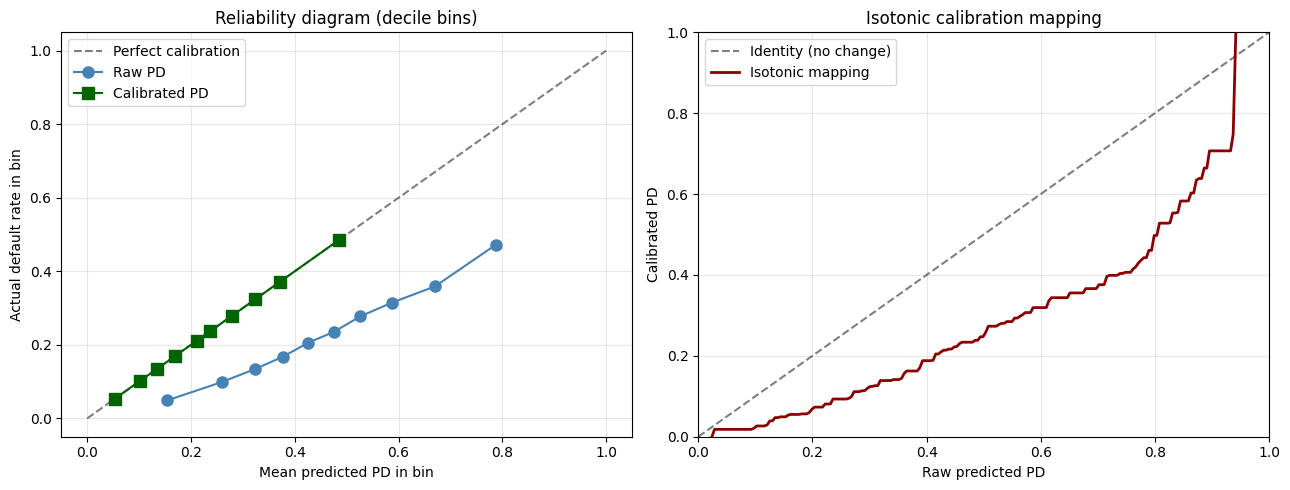

In [5]:
# Build calibrated bin stats
df["_pd_bin_cal"] = pd.qcut(df["pd_calibrated"], q=10, duplicates="drop")
calib_cal = (
    df.groupby("_pd_bin_cal", observed=True)
    .agg(mean_pred=("pd_calibrated", "mean"),
         actual=("target_default", "mean"))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: reliability diagram
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
axes[0].plot(calib_raw["mean_pred"], calib_raw["actual"],
             "o-", color="steelblue", label="Raw PD", markersize=8)
axes[0].plot(calib_cal["mean_pred"], calib_cal["actual"],
             "s-", color="darkgreen", label="Calibrated PD", markersize=8)
axes[0].set_xlabel("Mean predicted PD in bin")
axes[0].set_ylabel("Actual default rate in bin")
axes[0].set_title("Reliability diagram (decile bins)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: the isotonic mapping curve
x_grid = np.linspace(df["pred_default_prob"].min(),
                     df["pred_default_prob"].max(), 200)
y_grid = iso.predict(x_grid)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Identity (no change)")
axes[1].plot(x_grid, y_grid, "-", color="darkred", linewidth=2, label="Isotonic mapping")
axes[1].set_xlabel("Raw predicted PD")
axes[1].set_ylabel("Calibrated PD")
axes[1].set_title("Isotonic calibration mapping")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

# Tidy up bin columns
df = df.drop(columns=["_pd_bin_raw", "_pd_bin_cal"])

## 6. Set economic parameters

All economic assumptions are kept in a single dict so they are easy to find, modify, and reference in sensitivity analysis. These values are based on the U.S. consumer unsecured-loan industry around 2017:

| Parameter | Value | Source / Reasoning |
|---|---|---|
| LGD | 65% | LendingClub 10-K reports recoveries ~33%, so loss-given-default ≈ 67%. Industry standard 60–70% for unsecured consumer loans. |
| Funding cost | 3.5% / yr | Average funding cost for U.S. mid-size lending platforms in 2017. |
| Servicing cost | 1.0% / yr | Operating cost of maintaining a loan (collections, customer service). |
| Origination cost | $200 / loan | Fixed cost per originated loan (underwriting, KYC, disbursement). |

Every one of these values is a target for sensitivity analysis later.

In [6]:
PARAMS = {
    "lgd":            0.9013,    # Loss given default (fraction of EAD lost)
    "funding_cost":   0.035,   # Annual funding cost rate
    "servicing_cost": 0.010,   # Annual servicing cost rate (on outstanding)
    "origination_fee": 200.0,  # Fixed cost per loan ($)
    "ead_fraction":   0.5,     # EAD ≈ A_i × 0.5 (average outstanding at default)
    "avg_balance_fraction": 0.5,  # Average outstanding ≈ A_i × 0.5
}

for k, v in PARAMS.items():
    print(f"  {k:25s} = {v}")

  lgd                       = 0.9013
  funding_cost              = 0.035
  servicing_cost            = 0.01
  origination_fee           = 200.0
  ead_fraction              = 0.5
  avg_balance_fraction      = 0.5


## 7. Compute monthly payment via amortization

For an amortizing loan with principal $A$, monthly rate $r^m = r_{\text{annual}}/12$, and term $n$ months:

$$M = A \cdot \frac{r^m (1+r^m)^n}{(1+r^m)^n - 1}$$

We compute this from `loan_amnt`, `int_rate`, and `term_months`. We also cross-check against the `installment` field that came directly from LendingClub: the two should match closely. Any meaningful gap would suggest a unit error.

In [7]:
# Monthly rate as a decimal (int_rate is in percent, e.g. 13.56 -> 0.1356/12)
monthly_rate = df["int_rate"] / 100 / 12
n_months = df["term_months"]
principal = df["loan_amnt"]

df["monthly_payment"] = principal * (
    monthly_rate * (1 + monthly_rate) ** n_months
) / ((1 + monthly_rate) ** n_months - 1)

# Sanity check against LendingClub's installment field
df["_installment_diff"] = df["monthly_payment"] - df["installment"]
print("Monthly payment vs. LendingClub installment field:")
print(f"  Our calc mean:        ${df['monthly_payment'].mean():.2f}")
print(f"  LendingClub mean:     ${df['installment'].mean():.2f}")
print(f"  Mean abs difference:  ${df['_installment_diff'].abs().mean():.4f}")
print(f"  Max abs difference:   ${df['_installment_diff'].abs().max():.4f}")
print("  (should be < $0.10 — both formulas should yield identical results)")

df = df.drop(columns=["_installment_diff"])

Monthly payment vs. LendingClub installment field:
  Our calc mean:        $439.64
  LendingClub mean:     $439.64
  Mean abs difference:  $0.0116
  Max abs difference:   $405.3881
  (should be < $0.10 — both formulas should yield identical results)


In [8]:
diffs = (df['monthly_payment'] - df['installment']).abs()
print(df.loc[diffs > 50, ['id', 'loan_amnt', 'int_rate', 'term_months', 'installment', 'monthly_payment']].head(10))

               id  loan_amnt  int_rate  term_months  installment  monthly_payment
17529   116810985    35000.0     26.30           60       979.19      1054.141565
76887   107073710    33600.0     18.99           36      1077.33      1231.472399
106593   98728154    15000.0      6.00           36       390.24       456.329062
115680   97488980    35000.0      6.00           60       271.26       676.648054
127255   96602141     5000.0     11.44           36        59.91       164.737391


## 8. Compute the components of $\pi_i$

Break the formula into named columns so each piece is auditable. This makes it easy to check the math, do sensitivity, and explain the contribution of each component.

In [9]:
# Total interest income in the good-payment scenario
df["total_interest"] = df["monthly_payment"] * df["term_months"] - df["loan_amnt"]

# Average outstanding balance over the life of the loan
df["avg_balance"] = df["loan_amnt"] * PARAMS["avg_balance_fraction"]

# Years of life — used to scale annual rates
df["term_years"] = df["term_months"] / 12

# Cost components
df["funding_cost"] = PARAMS["funding_cost"] * df["avg_balance"] * df["term_years"]
df["servicing_cost"] = PARAMS["servicing_cost"] * df["avg_balance"] * df["term_years"]

# Net income in the good scenario
df["net_income_good"] = df["total_interest"] - df["funding_cost"] - df["servicing_cost"]

# Loss in the default scenario
df["ead"] = df["loan_amnt"] * PARAMS["ead_fraction"]
df["expected_loss"] = df["pd_calibrated"] * PARAMS["lgd"] * df["ead"]

print("Per-loan averages of each component:")
summary = df[["loan_amnt", "total_interest", "funding_cost", "servicing_cost",
              "net_income_good", "ead", "expected_loss"]].mean()
print(summary.to_string())

Per-loan averages of each component:
loan_amnt          14301.253093
total_interest      4568.648409
funding_cost         926.413432
servicing_cost       264.689552
net_income_good     3377.545425
ead                 7150.626547
expected_loss       1634.617245


## 9. Compute final expected profit $\pi_i$

Combine the components: the survival-weighted net income, minus the default-weighted expected loss, minus the fixed origination fee.

In [10]:
df["pi"] = (
    (1 - df["pd_calibrated"]) * df["net_income_good"]
    - df["pd_calibrated"] * PARAMS["lgd"] * df["ead"]
    - PARAMS["origination_fee"]
)

print("Distribution of expected profit pi (per loan, in dollars):")
print(df["pi"].describe().round(2).to_string())
print()
n_pos = (df["pi"] > 0).sum()
n_neg = (df["pi"] <= 0).sum()
print(f"Loans with pi > 0 (profitable in expectation):     {n_pos:,}  ({n_pos/len(df)*100:.1f}%)")
print(f"Loans with pi <= 0 (unprofitable in expectation):  {n_neg:,}  ({n_neg/len(df)*100:.1f}%)")
print()
print(f"Total pi if every loan approved:  ${df['pi'].sum():,.0f}")
print(f"Total pi if only pi>0 approved:   ${df.loc[df['pi'] > 0, 'pi'].sum():,.0f}")
print(f"  (the gap is the value optimization can capture)")

Distribution of expected profit pi (per loan, in dollars):
count    169321.00
mean        430.91
std        1649.65
min      -15972.75
25%        -271.36
50%          14.42
75%         657.70
max       21881.75

Loans with pi > 0 (profitable in expectation):     86,419  (51.0%)
Loans with pi <= 0 (unprofitable in expectation):  82,902  (49.0%)

Total pi if every loan approved:  $72,961,378
Total pi if only pi>0 approved:   $112,939,580
  (the gap is the value optimization can capture)


## 10. Diagnostic — distribution and structure of $\pi_i$

Three views to make sure the formula behaves sensibly:

1. **Histogram** of $\pi_i$ — should be roughly bell-shaped with a sizeable left tail of unprofitable loans.
2. **By LendingClub grade** — mean $\pi_i$ should *decrease* as we move from A to G (high-risk loans should be worth less).
3. **By calibrated PD decile** — mean $\pi_i$ should drop monotonically as PD rises.

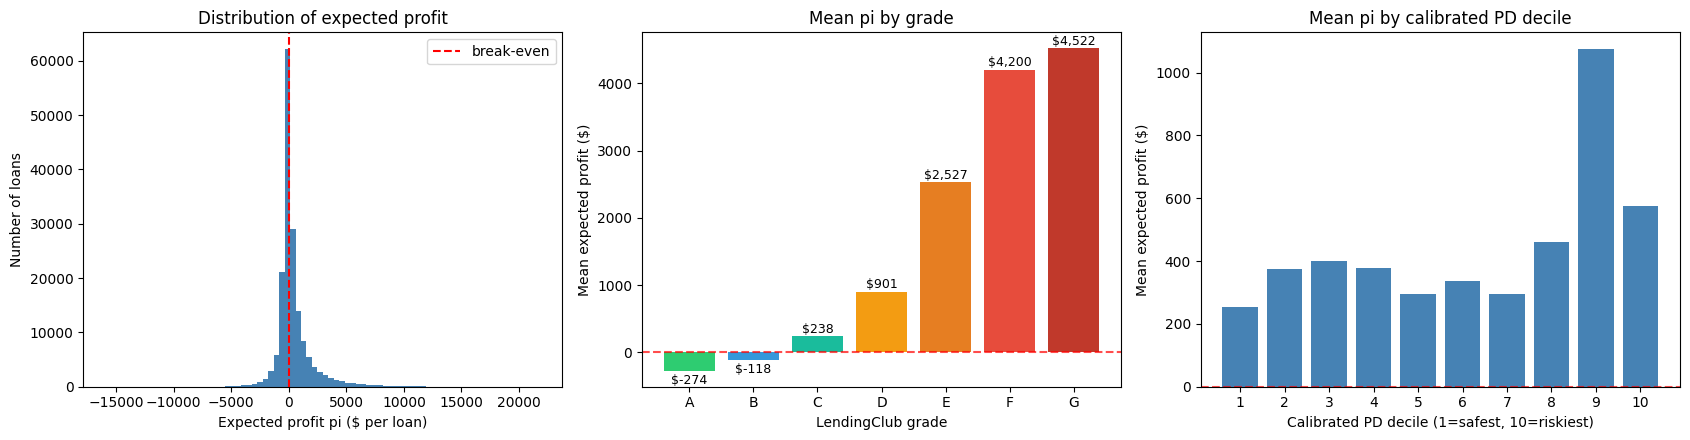

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel 1: distribution of pi
axes[0].hist(df["pi"], bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="red", linestyle="--", label="break-even")
axes[0].set_xlabel("Expected profit pi ($ per loan)")
axes[0].set_ylabel("Number of loans")
axes[0].set_title("Distribution of expected profit")
axes[0].legend()

# Panel 2: mean pi by grade
by_grade = df.groupby("grade", observed=True)["pi"].mean().sort_index()
colors = ["#2ecc71", "#3498db", "#1abc9c", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]
axes[1].bar(by_grade.index, by_grade.values, color=colors[:len(by_grade)])
axes[1].axhline(0, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("LendingClub grade")
axes[1].set_ylabel("Mean expected profit ($)")
axes[1].set_title("Mean pi by grade")
for i, v in enumerate(by_grade.values):
    axes[1].text(i, v + (10 if v >= 0 else -50),
                 f"${v:,.0f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)

# Panel 3: mean pi by calibrated PD decile
df["_pd_decile"] = pd.qcut(df["pd_calibrated"], q=10, duplicates="drop", labels=False) + 1
by_decile = df.groupby("_pd_decile")["pi"].mean()
axes[2].bar(by_decile.index, by_decile.values, color="steelblue")
axes[2].axhline(0, color="red", linestyle="--", alpha=0.7)
axes[2].set_xlabel("Calibrated PD decile (1=safest, 10=riskiest)")
axes[2].set_ylabel("Mean expected profit ($)")
axes[2].set_title("Mean pi by calibrated PD decile")
axes[2].set_xticks(range(1, 11))
df = df.drop(columns=["_pd_decile"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pi_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Detailed breakdown by grade — useful for the report
grade_summary = (
    df.groupby("grade", observed=True)
    .agg(n=("id", "count"),
         mean_pd_cal=("pd_calibrated", "mean"),
         mean_int_rate=("int_rate", "mean"),
         mean_loan_amnt=("loan_amnt", "mean"),
         mean_pi=("pi", "mean"),
         pct_profitable=("pi", lambda s: (s > 0).mean() * 100))
    .round(2)
    .sort_index()
)
print("Per-grade summary:")
print(grade_summary.to_string())

Per-grade summary:
           n  mean_pd_cal  mean_int_rate  mean_loan_amnt  mean_pi  pct_profitable
grade                                                                            
A      26890         0.10           6.99        12926.74  -274.28           19.18
B      47001         0.19          10.60        12961.16  -118.38           36.40
C      54919         0.26          14.27        14482.65   237.70           54.40
D      24521         0.30          18.76        15550.23   900.68           77.33
E      10214         0.34          24.71        17015.68  2527.50           95.26
F       3649         0.41          29.78        19112.58  4200.39           96.93
G       2127         0.44          30.88        20919.11  4521.75           96.19


## 11. Save `loans_with_profit.csv`

Save the enriched dataset including all the new calibration and profit columns. This file is the direct input to the next notebook (`03_optimization.ipynb`).

In [13]:
df.to_csv(PROFIT_OUTPUT_PATH, index=False)
print(f"Saved to: {PROFIT_OUTPUT_PATH}")
print(f"Shape: {df.shape}")
print(f"File size: {PROFIT_OUTPUT_PATH.stat().st_size / 1e6:.1f} MB")
print(f"\nNew columns added in this notebook:")
for c in ["pd_calibrated", "monthly_payment", "total_interest",
         "avg_balance", "term_years", "funding_cost", "servicing_cost",
         "net_income_good", "ead", "expected_loss", "pi"]:
    if c in df.columns:
        print(f"  - {c}")

Saved to: /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_with_profit.csv
Shape: (169321, 31)
File size: 49.8 MB

New columns added in this notebook:
  - pd_calibrated
  - monthly_payment
  - total_interest
  - avg_balance
  - term_years
  - funding_cost
  - servicing_cost
  - net_income_good
  - ead
  - expected_loss
  - pi
